# Machine Learning with Galactic Genesis: Predicting Stellar Ages

## Learning Goals
By the end of this tutorial, you will:

- Gain insite into the astrophysical mechanisms that predict age
- Have a trained machine learning (ML) model for predicting ages of SDSS APOGEE stars
- Understand some of the limits of your ML model

## Introduction 

A number of machine learning tools have been created for astrophysical research in the last decade, and no small number of catalogs accompany them. Published catalogs take months or even years to create, and are subject to high degree of quality control by their creators. But a simple ML model can be created with relatively little code, illustrating some of the core concepts behind these models.

## Imports
This tutorial requires four commonly used python packages

- numpy for efficienct math with arrays
- matplotlib for plotting
- astropy for reading fits table
- tensorflow for building an ML model

We also use some SDSS specific packages:
- semaphore for targeting flags
- sdss_access for file paths
Missing packages can be installed via `pip install numpy matplotlib astropy tensorflow sdss-semaphore sdss-access`

You may not need to use sdss-access and can instead change the path to wherever your ASPCAP file is saved.

In [1]:
#Import some things
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import fits, ascii
from astropy.table import Table
from astropy.coordinates import SkyCoord
from tensorflow import keras

import sdss_access

In [2]:
#by default the machine learning stuff tries to use a GPU. 
#If you don't have a GPU (or want to use a CPU instead you need something like the following code)

os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

``sdss-access`` is a convenient way to access SDSS data. Using the structure below, we can check if the file has been downloaded before, and if not download it to the location expected by ``sdss-access``, then read it in.

Note: the first time the file is downloaded will take some time, depending on your internet connection it could be quite awhile.

In [3]:
sdss_path = sdss_access.path.Path(release='dr20', verbose=True)
allstar_file = sdss_path.full('astraAllStarASPCAP', v_astra='0.6.0')
access = sdss_access.Access(release='dr19', verbose=True)

if not sdss_path.exists('',full=allstar_file):
    # if the file does not exist locally, this code will download the data.
    access.remote()
    access.add('astraAllStarASPCAP', v_astra='0.6.0')
    access.set_stream()
    access.commit()
    allstar_file = sdss_path.full('astraAllStarASPCAP', v_astra='0.6.0')

tb = fits.open(allstar_file)
header=tb[2].header
data = tb[2].data 


There are examples of different ways one might filter the allStar data in other SDSS tutorials, here we will use a relatively simple cut.

In [4]:
# mask_gaia = (data['zgr_plx']>0)
# data_masked=data[mask_gaia]

good_gg_inds = (data["flag_bad"] == 0) & (data["spectrum_flags"] == 0) & (data["snr"] > 40)
data_masked = data[good_gg_inds]
print(len(data_masked))

513236


The APOKASC-3 Catalog, Pinsonneault et al. 2025 https://ui.adsabs.harvard.edu/abs/2025ApJS..276...69P/abstract

In [5]:
#Reading in the table, making sure all the tables have a column named Age in Gyr
# and that every star in the table has an Age
apokasc3raw = Table.read("Pinsonneault2025.txt", format="ascii.cds")
# there were two age columns, one for Red Clump and one for Red Giant Branch so we combine them
ageRC= np.array(apokasc3raw['AgeRC']*(apokasc3raw['EvolState']=='RC'))
rcnans = np.isnan(ageRC) #removing nans from this version of the table.
ageRC[rcnans] = 0
ageRGB = np.array(apokasc3raw['AgeRGB']*(apokasc3raw['EvolState']=='RGB'))
rgbnans = np.isnan(ageRGB) #removing nans from this version of the table.
ageRGB[rgbnans] = 0
apokasc3raw['Age'] = (ageRC + ageRGB)

hasagea3 = np.where((apokasc3raw['Age'] == apokasc3raw['Age']) & (apokasc3raw['Age'] > 0.1))
agedata = apokasc3raw[hasagea3]
agedata
print(len(agedata))

12291


Now we need to figure which stars are in both the age list and the Milky Way Mapper spectroscopy sample, and what their array elements are.

In [6]:
#Option 3 APOKASC-3 Pinsonneault et al. 2025
intersect, ind_a, ind_b = np.intersect1d(data_masked['gaia_dr3_source_id'],agedata['GaiaDR3'], return_indices=True) 

print(len(ind_b))

7279


It's great that you have ages for a few thousand stars, but wouldn't it be better to have ages for a sizable fraction of the million stars in the full sample? We know from stellar evolution that the age of the star should be correlated with it's position on the HR diagram, temperature and surface gravity; its composition, metallicity and $\alpha$ abundance; and its mass, which scales with the carbon and nitrogen at the surface for giants. So we should in theory be able to come up with some scheme that can learn these relationships. In this case the scheme we're going to use is a neural network. 

We are going set up a data structure that contains only the parameters we want to use for training the neural network. We also want to remove anything that has a NaN in it, and normalize things for simplicity.

In [7]:
fullx = np.dstack([data_masked['teff'][ind_a],data_masked['logg'][ind_a], data_masked['m_h_atm'][ind_a],
                   data_masked['alpha_m_atm'][ind_a], data_masked['c_h'][ind_a], data_masked['n_h'][ind_a]])[0]

fully = np.dstack([agedata['Age'][ind_b]])[0] 

#remove non-finite entries!
mask = np.all(np.isfinite(fullx), axis=1) & np.all(np.isfinite(fully), axis=1)
fullx, fully = fullx[mask], fully[mask]

scaling_x = np.median(fullx, axis=0)
scaling_y = np.median(fully, axis=0)

fullx, fully = fullx/scaling_x, fully/scaling_y

The "hyperparameters" of a neural network are important, and can effect the accuracy of the resulting model. Some digging in the literature e.g. [Tayar et al. 2023](https://ui.adsabs.harvard.edu/abs/2023RNAAS...7..273T/abstract) or similar, can inform our choices for number of layers, neurons per layer, and training iterations. We won't concern ourselfves with the activation function in this exercise and stick with commonly uses relu function.

In [8]:
neurons_per_layer=12

iterations=100

#start with an input layer
inputs = keras.Input(shape=(6,))
#now we add the Dense layers (indicating the previous layer in the brackets following the layer declaration

#change this part if you're changing the number of layers
layer1 = keras.layers.Dense(neurons_per_layer, activation='relu')(inputs)
layer2 = keras.layers.Dense(neurons_per_layer, activation='relu')(layer1)
layer3 = keras.layers.Dense(neurons_per_layer, activation='relu')(layer2)
layer4 = keras.layers.Dense(neurons_per_layer, activation='relu')(layer3)

outputs = keras.layers.Dense(1)(layer4)

# then we put that all together in the Model object
model = keras.Model(inputs=inputs, outputs=outputs, name='test')
#and we can print a summary to check it all went to plan
model.summary()

Model: "test"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 565 (2.21 KB)

 Trainable params: 565 (2.21 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(loss=keras.losses.MeanSquaredError(), optimizer=keras.optimizers.Adam(), metrics=['accuracy'])

When you train a machine learning model, you always want to leave out a testing set, a set of stars where you know what the correct answer, but the neural network hasn't seen, so that you can test its response.

In [10]:
tenpercent=len(agedata['Age'][ind_b])//10 #figure out what ten percent of this set of age data is

trainbin=slice(0,-1*tenpercent-1)
testing=slice(-1*tenpercent,-1)


x_train, y_train = fullx[trainbin], fully[trainbin]
x_test, y_test = fullx[testing], fully[testing]

Okay now train the neural network

In [11]:
model.fit(x_train, y_train, epochs=100, validation_split=0.05, batch_size=300)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0000e+00 - loss: 4.0611 - val_accuracy: 0.0000e+00 - val_loss: 3.1663
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0000e+00 - loss: 2.3645 - val_accuracy: 0.0000e+00 - val_loss: 1.9959
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 1.7340 - val_accuracy: 0.0000e+00 - val_loss: 1.5017
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0000e+00 - loss: 1.3391 - val_accuracy: 0.0000e+00 - val_loss: 1.1572
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0000e+00 - loss: 1.0836 - val_accuracy: 0.0000e+00 - val_loss: 1.0009
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0000e+00 - loss: 0.9524 - val_accuracy: 0.0000e+00 - val_loss: 0.8658
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - accuracy: 0.0000e+00 - loss: 0.8304 - val_accuracy: 0.0000e+00 - val_loss: 0.7138
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step 

Now that you have trained the neural network, use it to predict what the ages of the stars in the testing set should be.

In [12]:
predictions = model.predict(x_test)
print(len(predictions))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
726


How well did your neural network do? Let's plot and print things! The metric we're going to use is whether the neural network predicted age is within 30% of the correct answer or not.

In [13]:
metric = 0.3 #is the accuracy better than 30%?
goodfit = np.where(((1-metric) < predictions/y_test) & ((1+metric) > predictions/y_test)) 
badfit = np.where(((1-metric) > predictions/y_test) | ((1+metric) < predictions/y_test))

print ('With ', neurons_per_layer, 'neurons per layer, ', '3 layers, and ', iterations, 'iterations')
print ('using the training set', trainbin)
print (len(goodfit[0])/len(y_test)*100, 'percent of the ages are good')
print (len(badfit[0])/len(y_test)*100, 'percent of the ages are bad')

With  12 neurons per layer,  3 layers, and  100 iterations
using the training set slice(0, -728, None)
65.42699724517907 percent of the ages are good
34.57300275482093 percent of the ages are bad


(0.0, 14.0)

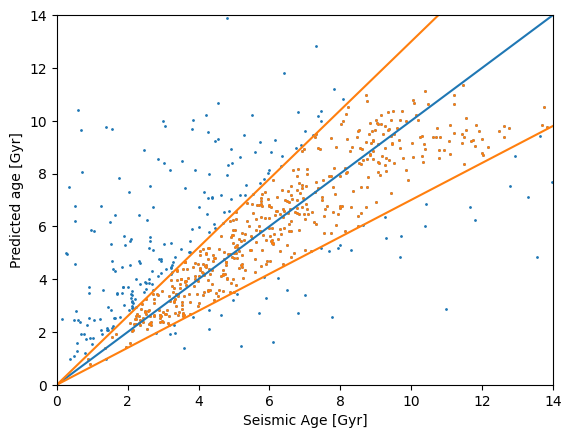

In [14]:
#remember that we scaled our input/output
plt.scatter( (y_test * scaling_y), (predictions * scaling_y), s=1.)
plt.scatter( (y_test[goodfit] * scaling_y), (predictions[goodfit] * scaling_y), s=1.)
plt.xlim(0., 14.)
plt.plot([0., 14.], [0., 14.])
plt.plot([14, 0, 14], [14 * (1 - metric), 0, 14 * (1 + metric)])

plt.ylabel(r'Predicted age [Gyr]')
plt.xlabel(r'Seismic Age [Gyr]')
plt.ylim(0,14)

Now that you have a sense of how well your neural network is doing, forge ahead and predict ages for the whole data sample!

In [15]:
DR19x = np.dstack([data_masked['teff'],data_masked['logg'], data_masked['m_h_atm'],
                   data_masked['alpha_m_atm'], data_masked['c_h'], data_masked['n_h']])[0]
print(len(data_masked['teff']))

DR19x = DR19x/scaling_x
predictionsDR19 = model.predict(DR19x)

513236
16039/16039 ━━━━━━━━━━━━━━━━━━━━ 2s 147us/step


The predictions are normalized for the ML model, so we should transform them back to age space. We'll also create a mask for the DR19 data (note any star with an input nan will come out nan).

Next, we'll do some quick coordinate conversion so we can use.

In [16]:
ages = predictionsDR19[:, 0] * scaling_y

nan_mask = np.where(np.isfinite(ages))

data = data_masked[nan_mask]

# use skycoord to input information, correct units
c = SkyCoord(ra=data['ra']*u.deg, dec=data['dec']*u.deg, 
             distance=(data['r_med_geo'])*u.pc,
             pm_ra_cosdec=data['pmra']*u.mas/u.yr, 
             pm_dec=data['pmde']*u.mas/u.yr,
            radial_velocity=data['v_rad']*u.km/u.s) 

# transform to galactocentric coordinate
# the assumed values are from Schonrich et al 2010, and from Gravity collab 2022
galcen = c.transform_to(coord.Galactocentric(galcen_v_sun=[8, 254, 8] * u.km / u.s, galcen_distance=8.275 * u.kpc))

# Extract the galactic coordinates and motions
x = galcen.x.value
y = galcen.y.value
z = galcen.z.value

R = np.sqrt(x**2+y**2)

 Make a map of the ages of the stars in the sample (color) as a function of the Galactocentric radius and the galactic height.

(0.0, 30.0)

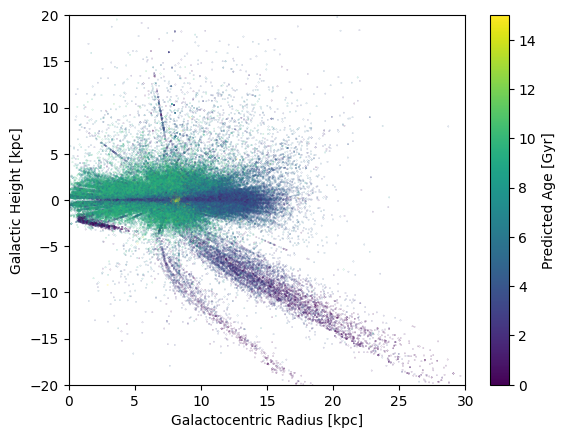

In [17]:
plt.scatter( R/1000,z/1000,c=ages[nan_mask],vmin=0,vmax=15,s=0.01)
plt.colorbar(label='Predicted Age [Gyr]')
plt.ylabel(r'Galactic Height [kpc]')
plt.xlabel(r'Galactocentric Radius [kpc]')
plt.ylim(-20,20)
plt.xlim(0,30)

For a few dozen lines of code, this result seeems quite good! The thin disk is younger, the thick disk is older, and we even see the younger flaring in the outer Galaxy (see e.g. [Stone-Martinez et al. 2025](https://ui.adsabs.harvard.edu/abs/2025AJ....170...66S/abstract).

But what's going on with those streaky bits far from the Galaxy that are reported as young?

Text(0.5, 0, 'Distance Uncertainty (pc)')

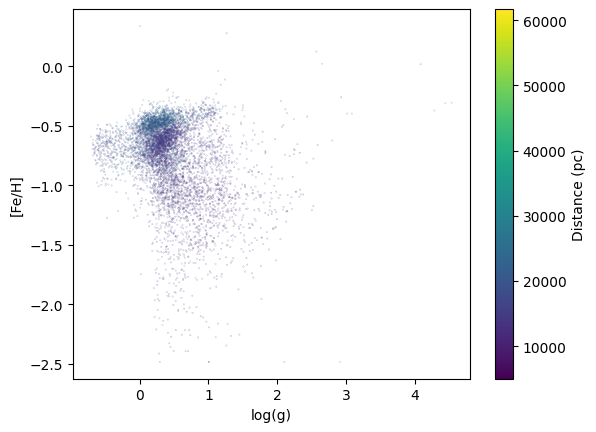

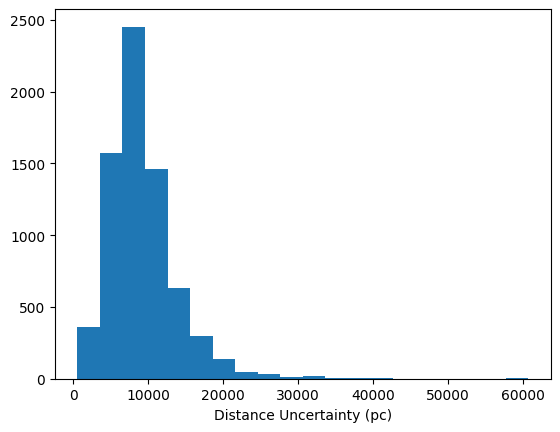

In [18]:
w = np.where((R > 5e3) & (z <-5e3))

prob = data[w]

plt.scatter(prob["logg"], prob["fe_h"], c=prob["r_med_geo"],s=0.01)
plt.colorbar(label='Distance (pc)')
plt.ylabel(r'[Fe/H]')
plt.xlabel(r'log(g)')

plt.figure()
plt.hist(prob["r_hi_geo"] - prob["r_lo_geo"], bins=20)
plt.xlabel("Distance Uncertainty (pc)")

We can make a few important observations. First, this "problematic" sample varies is all low metallicity, giant stars. Given their estimated distances, of course they have to be giants.

From the histogram, we can also see the very large distance uncertainties in this sample (almost on the order of the estimated distances). So in fact those streaks may not be streaks at all, they could easily be blobs, and in fact are likely the MCs.

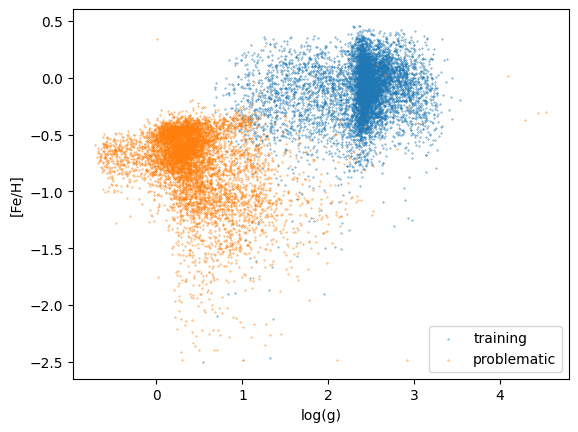

In [19]:
plt.scatter(data_masked['logg'][ind_a], data_masked['m_h_atm'][ind_a], label="training", s=0.1)
plt.scatter(prob["logg"], prob["fe_h"], s=0.1, label="problematic")
plt.ylabel(r'[Fe/H]')
plt.xlabel(r'log(g)')
plt.legend()

From this plot, it is immediately obvious we should doubt the ML results for the "problematic" sample. While the training sample contains giant stars, the problematic sample is almost exlusively much larger giants, probably mostly AGB stars. Additionally, the problematic sample is almost entirely lower metallicity than the training sample. With effectively no representation in the training sample, we should not expect the ML model to predict accurate ages for the problematic sample.

This is always a concern for ML techniques! Models cannot interpret data they were not trained on.

### About this notebook
This notebook was created to explore machine learning with APOGEE data.

__Authors__: Jamie Tayar, edited by John Donor

__Last Update__: 2026 Feb 19

If you use `astropy` for published research, please cite the authors. Follow this link for more information about citing astropy:

- [Citing `astropy`
](https://www.astropy.org/acknowledging.html)

And of course please [cite](https://sdss.org/collaboration/citing-sdss/) SDSS when you use our data.